# Assignment: Pandas Fundamentals with Earthquake Data

# 1) Use Pandas’ read_csv function directly on this URL to open it as a DataFrame

In [2]:
# (Don’t use any special options). Display the first few rows and the DataFrame info.
# You should have seen that the dates were not automatically parsed into datetime types.

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
# open dataset from URL
df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv')

# display first few rows
print("First 5 rows of dataset:")
display(df.head())

# display DataFrame
print("\nDataFrame Info:")
df.info()

First 5 rows of dataset:


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120108 entries, 0 to 120107
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       120108 non-null  object 
 1   latitude   120108 non-null  float64
 2   longitude  120108 non-null  float64
 3   depth      120107 non-null  float64
 4   mag        120065 non-null  float64
 5   magType    120065 non-null  object 
 6   nst        59688 non-null   float64
 7   gap        94935 non-null   float64
 8   dmin       85682 non-null   float64
 9   rms        119716 non-null  float64
 10  net        120108 non-null  object 
 11  id         120108 non-null  object 
 12  updated    120108 non-null  object 
 13  place      120108 non-null  object 
 14  type       120108 non-null  object 
dtypes: float64(8), object(7)
memory usage: 13.7+ MB


# 2) Re-read the data in such a way that all date columns are identified as dates and the earthquake ID is used as the index

In [3]:
# Verify that this worked using the head and info functions.

In [93]:
# parse_dates=['time'] converts the text dates into actual date objects ???
df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv', index_col='id', parse_dates=['time'])

# verify changes with header
print("First 5 rows (ID is now index):")
display(df.head())

# verify changes for df
print("\nDataFrame Information (Check for 'time'):")
df.info()

First 5 rows (ID is now index):


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake



DataFrame Information (Check for 'time'):
<class 'pandas.core.frame.DataFrame'>
Index: 120108 entries, ak11155107 to ak11453389
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   time       120108 non-null  datetime64[ns]
 1   latitude   120108 non-null  float64       
 2   longitude  120108 non-null  float64       
 3   depth      120107 non-null  float64       
 4   mag        120065 non-null  float64       
 5   magType    120065 non-null  object        
 6   nst        59688 non-null   float64       
 7   gap        94935 non-null   float64       
 8   dmin       85682 non-null   float64       
 9   rms        119716 non-null  float64       
 10  net        120108 non-null  object        
 11  updated    120108 non-null  object        
 12  place      120108 non-null  object        
 13  type       120108 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(5)
memory usage: 13.7+ M

# 3) Use describe to get the basic statistics of all the columns

In [7]:
# Note the highest and lowest magnitude of earthquakes in the databse.

In [94]:
# use describe -> basic statistics
statistics = df.describe()
# display stats
print("Basic stats:")
display(statistics)

Basic stats:


,time,latitude,longitude,depth,mag,nst,gap,dmin,rms
count,120108,120108.000000,120108.000000,120107.000000,120065.000000,59688.000000,94935.000000,85682.000000,119716.000000
mean,2014-07-05 09:10:37.116720128,38.399579,-99.961402,28.375029,1.793958,17.878284,124.048978,0.893198,0.358174
min,2014-01-01 00:01:16.610000,-73.462000,-179.998900,-9.900000,-0.970000,0.000000,9.000000,0.000000,0.000000
25%,2014-04-08 03:43:10.768999936,34.228917,-147.742025,4.100000,0.820000,8.000000,74.000000,0.020760,0.070000
50%,2014-07-07 10:44:06.035000064,38.805300,-120.832000,9.200000,1.400000,14.000000,107.000000,0.073670,0.200000
75%,2014-09-30 23:36:40.595000064,53.889500,-116.068100,22.880000,2.400000,22.000000,155.000000,0.447000,0.590000
max,2014-12-31 23:54:33.900000,86.651400,179.998000,697.360000,8.200000,365.000000,356.400000,64.498000,8.460000
std,NaN,21.938258,82.996858,62.215416,1.343466,14.911369,68.518595,2.903966,0.364046


In [7]:
# highest magnitude
df['mag'].max()

8.2

In [8]:
# lowest magnitude
df['mag'].min()

-0.97

# 4) Use nlargest to get the top 20 earthquakes by magnitude

In [42]:
# https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.nlargest.html
# Examine the structure of the place column. The state / country information seems to be in there. How would you get it out?

In [95]:
# nlargest -> top 20 EQ by magnitude
top_20 = df.nlargest(20, 'mag')
(top_20[['mag', 'place']])

,mag,place
id,,
usc000nzvd,8.2,"94km NW of Iquique, Chile"
usc000rki5,7.9,"19km SE of Little Sitkin Island, Alaska"
usc000p27i,7.7,"53km SW of Iquique, Chile"
usc000phx5,7.6,"93km SSE of Kirakira, Solomon Islands"
usb000pr89,7.5,"70km SW of Panguna, Papua New Guinea"
usc000piqj,7.4,"112km S of Kirakira, Solomon Islands"
usb000slwn,7.3,"74km S of Intipuca, El Salvador"
usb000pq41,7.2,"33km ESE of Petatlan, Mexico"
usc000pft9,7.1,"56km WSW of Panguna, Papua New Guinea"


# 5) Extract the state or country using Pandas text data functions

In [11]:
# Add it as a new column to the dataframe called country. Note that some of the “countries” are actually U.S. states.

In [96]:
# new 'country' column
df['country'] = df['place'].str.split(',').str[-1]
display(df[['place', 'country']].head())

,place,country
id,,
ak11155107,"26km S of Redoubt Volcano, Alaska",Alaska
nn00436847,"32km S of Alamo, Nevada",Nevada
ak11151142,"12km NNW of North Nenana, Alaska",Alaska
ak11151135,"22km S of Cantwell, Alaska",Alaska
ci37171541,"10km WNW of Progreso, Mexico",Mexico


# 6) Display each unique value from the new column

In [18]:
# https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.unique.html

In [97]:
df['country'].unique()
print(unique_countries)

[' Alaska' ' Nevada' ' Mexico' ' California' ' Papua New Guinea'
 ' New Zealand' ' Missouri' 'South of the Fiji Islands' ' Montana'
 ' British Virgin Islands' ' Washington' ' Oregon' ' Canada' ' Fiji'
 'Wyoming' ' Antarctica' ' Chile' ' Utah' ' Indonesia' ' Solomon Islands'
 ' Micronesia' ' Oklahoma' ' Hawaii' ' Wyoming' ' Russia' ' Arizona'
 ' Philippines' ' Bolivia' ' Greece' ' Japan' ' Puerto Rico' ' Iran'
 ' Tonga' ' Wallis and Futuna' ' Colorado' ' Guam' ' CA' 'Carlsberg Ridge'
 ' Idaho' ' Pakistan' 'Off the west coast of northern Sumatra' ' Burma'
 ' China' ' Peru' 'Off the east coast of the North Island of New Zealand'
 ' Costa Rica' 'Reykjanes Ridge' ' East Timor' 'Central East Pacific Rise'
 'Mid-Indian Ridge' ' Japan region' ' Northern Mariana Islands'
 ' El Salvador' ' Samoa' 'Northern Mid-Atlantic Ridge' ' Taiwan'
 ' Arkansas' ' South Sandwich Islands' ' Colombia' ' Dominican Republic'
 ' Argentina' ' Texas' ' New Hampshire' ' Saint Helena'
 'West of Vancouver Island' ' Tan

# 7) Create a filtered dataset that only has earthquakes of magnitude 4 or larger and

In [98]:
filtered_df = df[df['mag'] >= 4]
display(filtered_df.head())

print(f"Number of earthquakes with magnitude >= 4: {len(filtered_df)}")

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
usc000mqlp,2014-01-31 23:08:03.660,-4.9758,153.9466,110.18,4.2,mb,NaN,98.0,1.940,0.61,us,2014-04-08T01:43:19.000Z,"115km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea
usc000mqln,2014-01-31 22:54:32.970,-28.1775,-177.9058,95.84,4.3,mb,NaN,104.0,1.063,1.14,us,2014-04-08T01:43:19.000Z,"120km N of Raoul Island, New Zealand",earthquake,New Zealand
usc000mqls,2014-01-31 22:49:49.740,-23.1192,179.1174,528.34,4.4,mb,NaN,80.0,5.439,0.95,us,2014-04-08T01:43:19.000Z,South of the Fiji Islands,earthquake,South of the Fiji Islands
usc000mf1x,2014-01-31 22:19:44.330,51.1569,-178.0910,37.50,4.2,mb,NaN,NaN,NaN,0.83,us,2014-04-08T01:43:19.000Z,"72km E of Amatignak Island, Alaska",earthquake,Alaska
usc000mqlm,2014-01-31 21:56:44.320,-4.8800,153.8434,112.66,4.3,mb,NaN,199.0,1.808,0.79,us,2014-04-08T01:43:19.000Z,"100km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea


Number of earthquakes with magnitude >= 4: 17547


# 8) Using the filtered dataset (magnitude > 4), count the number of earthquakes in each country/state. Make a bar chart of this number for the top 5 locations with the most earthquakes

In [28]:
# Location name on the x axis, Earthquake count on the y axis

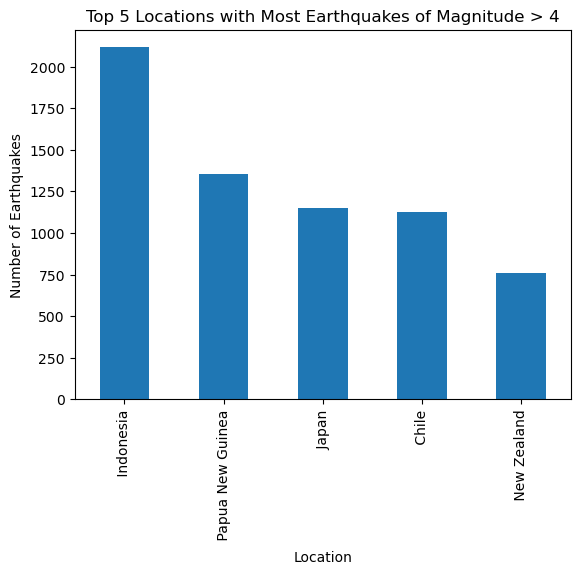

In [99]:
# .head(5) to get top 5
top_5_counts = filtered_df['country'].value_counts().head(5)

# plot as a bar chart
top_5_counts.plot(kind='bar')

plt.xlabel('Location')
plt.ylabel('Number of Earthquakes')
plt.title('Top 5 Locations with Most Earthquakes of Magnitude > 4')
plt.show()

# 9) Make a histogram the distribution of the Earthquake magnitudes

In [36]:
# https://pandas.pydata.org/pandas-docs/version/0.23/generated/pandas.DataFrame.hist.html 
# https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html
# Do one subplot for the filtered and one for the unfiltered dataset. 
# Use a Logarithmic scale. What sort of relationship do you see?

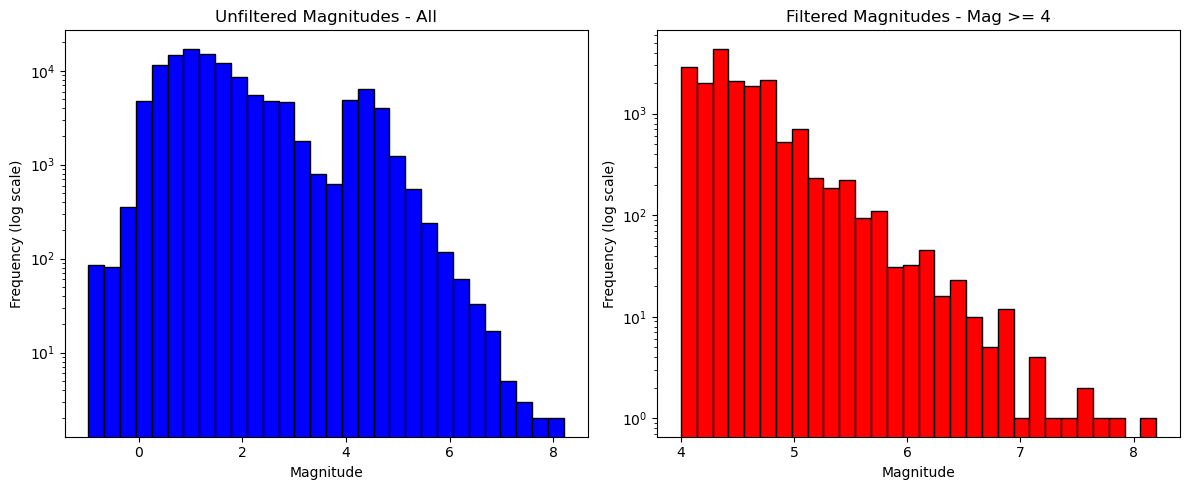

In [100]:
# side-by-side subplots 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# unfiltered
plt.subplot(1, 2, 1)
axes[0].hist(df['mag'], bins=30, log=True, color='blue', edgecolor='black')
axes[0].set_title('Unfiltered Magnitudes - All')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Frequency (log scale)')

# filtered (mag >= 4)
plt.subplot(1, 2, 2)
axes[1].hist(filtered_df['mag'], bins=30, log=True, color='red', edgecolor='black')
axes[1].set_title('Filtered Magnitudes - Mag >= 4')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

In [42]:
# Use a Logarithmic scale. What sort of relationship do you see?
# Answer: I see an inverse relationship - the higher magnitude earthquakes are less frequent. 
# This drop off in frequency is more severe than it looks on the graphs, given the log scale being used on the y-axis.

# 11) Visualize the locations of earthquakes by making a scatterplot of their latitude and longitude

In [64]:
# Use a two-column subplot with both the filtered and unfiltered datasets. Color the points by magnitude. Make it pretty!!!
# What difference do you note between the filtered and unfiltered datasets?

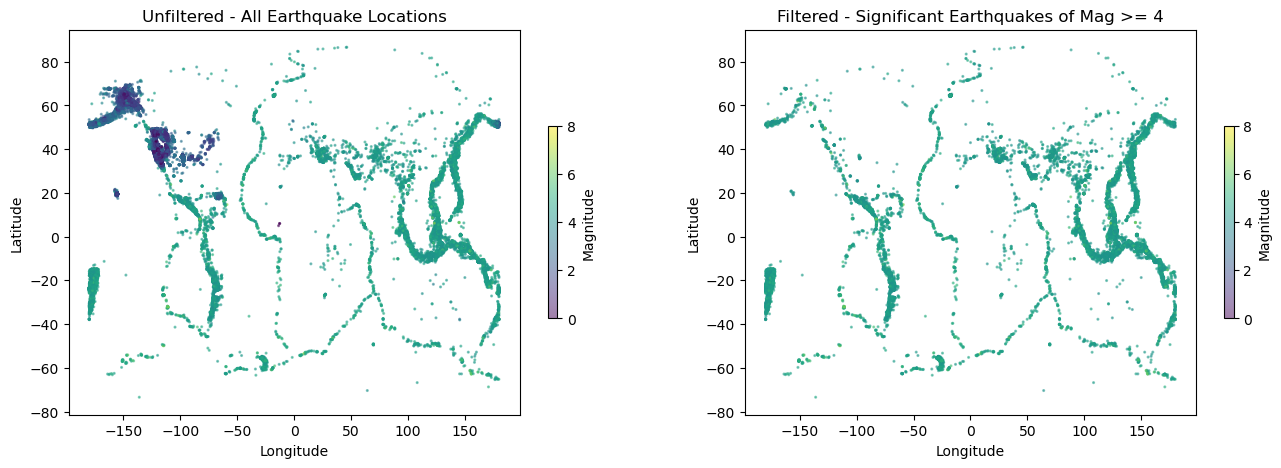

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# unfiltered
plt.subplot(1, 2, 1)
sc0 = axes[0].scatter(df['longitude'], df['latitude'], c=df['mag'], cmap='viridis', s=1.5, alpha=0.5, vmin=0, vmax=8)

fig.colorbar(sc0, ax=axes[0], label='Magnitude', shrink=0.5)
axes[0].set_title('Unfiltered - All Earthquake Locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# filtered
plt.subplot(1, 2, 2)
sc1 = axes[1].scatter(filtered_df['longitude'], filtered_df['latitude'], 
                     c=filtered_df['mag'], cmap='viridis', s=1.5, alpha=0.5, vmin=0, vmax=8)

fig.colorbar(sc1, ax=axes[1], label='Magnitude', shrink=0.5)
axes[1].set_title('Filtered - Significant Earthquakes of Mag >= 4')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.show()

In [65]:
# What difference do you note between the filtered and unfiltered datasets?
# Answer: The filtered data set shows a slgihtly more clear location of the Ring of Fire region associated with earthquakes.
# The unfiltered data set has more 'noise' with the additional data points, since the smaller tremors have a further reach.
# The more intense seismic activity is located at or close to seismic faults.